# Telecom Customer Churn Prediction

# Notebook 02 – Exploratory Data Analysis (EDA)

### Author

Kareem Ibraheem Bola

### Programme

DATA SCIENCE NEXTGEN COHORT

### Purpose

This notebook explores the IBM Telco Customer Churn dataset to identify patterns, trends, and business insights associated with customer churn.

The analysis aims to answer key business questions through descriptive statistics and data visualization before feature engineering and predictive modelling.

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
# Global plotting configuration

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120

In [2]:
# ==========================================
# Load Dataset
# ==========================================

DATA_PATH = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
# ==========================================
# Prepare TotalCharges for Analysis
# ==========================================

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].str.strip(),
    errors="coerce"
)

print("TotalCharges converted successfully.")

TotalCharges converted successfully.


In [4]:
# Target Variable Distribution

df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [5]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

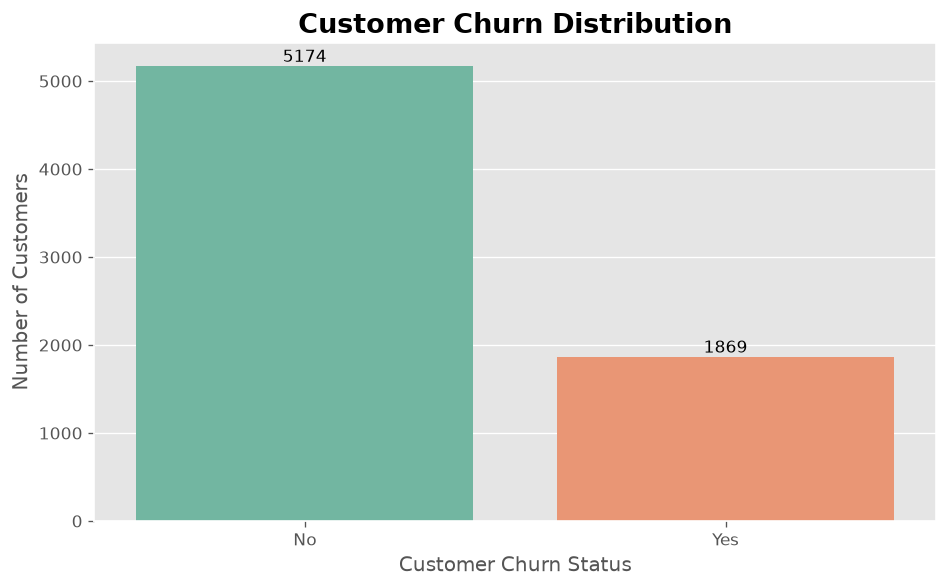

In [9]:
# ==========================================
# Customer Churn Distribution
# ==========================================

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",          # avoids future seaborn deprecation warnings
    palette="Set2",
    legend=False
)

# Add count labels above bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Customer Churn Status")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [10]:
churn_percent = (
    df["Churn"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

churn_percent

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

### Business Observation

- Approximately **73%** of customers remained with the telecom provider, while **27%** churned.
- Although the majority of customers were retained, more than one-quarter of customers left the company.
- This represents a significant revenue risk for the telecom provider.
- The dataset exhibits moderate class imbalance, which should be considered during model evaluation.
- Understanding the characteristics of churned customers will help design effective retention strategies.

# Customer Profile Analysis

Understanding the demographic and service characteristics of customers helps identify the composition of the customer base before investigating churn patterns.

This section summarizes the major customer groups.

In [11]:
# ==========================================
# Gender Distribution
# ==========================================

gender_counts = df["gender"].value_counts()

gender_counts

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [ ]:
# ==========================================
# Gender Distribution in %
# ==========================================
gender_percentage = (
    df["gender"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

gender_percentage

gender
Male      50.48
Female    49.52
Name: proportion, dtype: float64

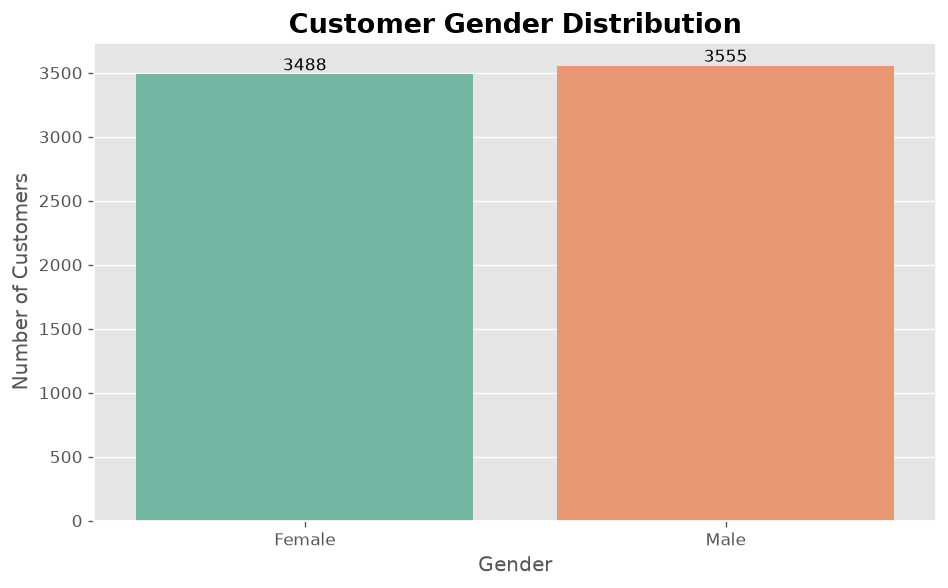

In [ ]:
# ==========================================
# Gender Distribution visualization
# ==========================================
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="gender",
    hue="gender",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Gender Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Business Observation

- The customer base is almost evenly split between male and female customers, with **3,555 males (50.48%)** and **3,488 females (49.52%)**.
- This balanced distribution indicates that the telecom company's customer base is not dominated by either gender.
- Since both genders are similarly represented, gender alone is unlikely to explain customer churn and should be evaluated alongside other customer characteristics.

In [14]:
# ==========================================
# Senior Citizen Distribution
# ==========================================

df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [ ]:
# ==========================================
# Senior Citizen Distribution in %
# ==========================================

(
    df["SeniorCitizen"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

SeniorCitizen
0    83.79
1    16.21
Name: proportion, dtype: float64

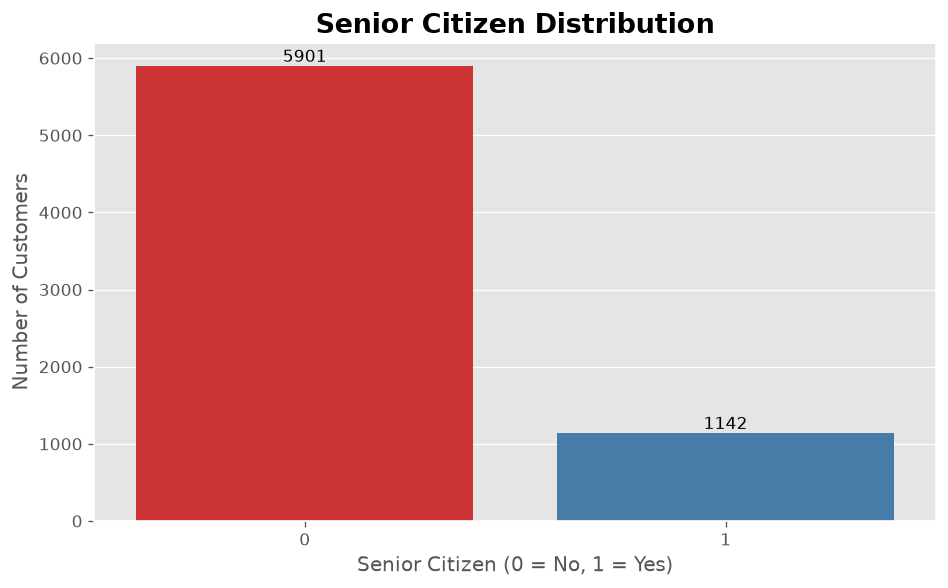

In [ ]:
# ==========================================
# Senior Citizen Distribution Visualization
# ==========================================

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="SeniorCitizen",
    palette="Set1",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Senior Citizen Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Business Observation

- The majority of customers (**5,901; 83.79%**) are **not senior citizens**, while **1,142 customers (16.21%)** are senior citizens.
- This indicates that the company's customer base primarily consists of younger or middle-aged individuals.
- Although senior citizens represent a smaller segment of the customer population, further analysis is required to determine whether they experience higher churn rates than other customers.

In [ ]:
# ==========================================
# Senior Citizen Distribution   
# ==========================================
df["Partner"].value_counts()

Partner
No     3641
Yes    3402
Name: count, dtype: int64

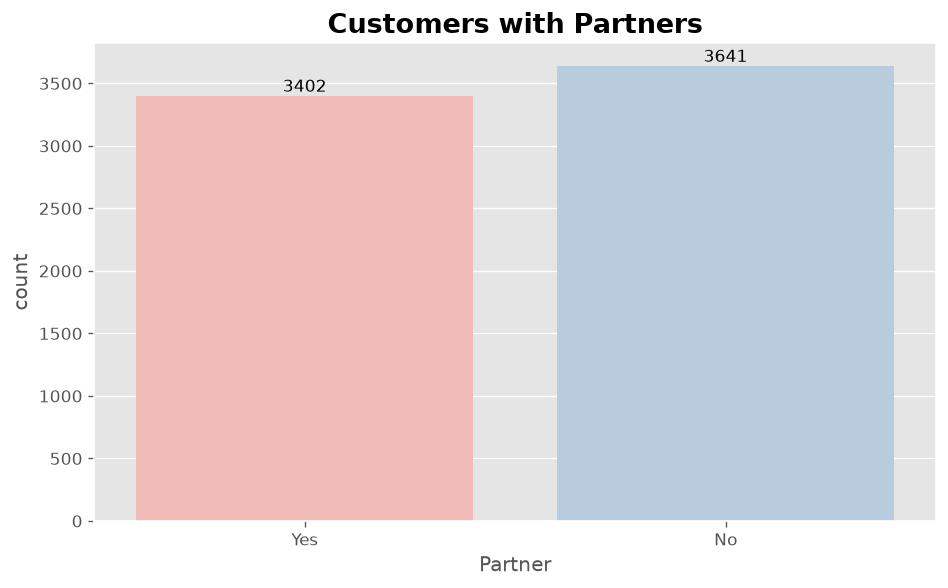

In [ ]:
# ==========================================
# Senior Citizen Distribution Visualization
# ==========================================
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Partner",
    hue="Partner",
    palette="Pastel1",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customers with Partners", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### Business Observation

- Customers are fairly balanced between those with partners (**3,402; 48.30%**) and those without partners (**3,641; 51.70%**).
- Slightly more customers do not have partners, suggesting a diverse customer demographic.
- Relationship status may influence customer loyalty and service usage, making it a relevant variable for subsequent churn analysis.

In [ ]:
# ==========================================
# Dependents Distribution
# ==========================================
df["Dependents"].value_counts()

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

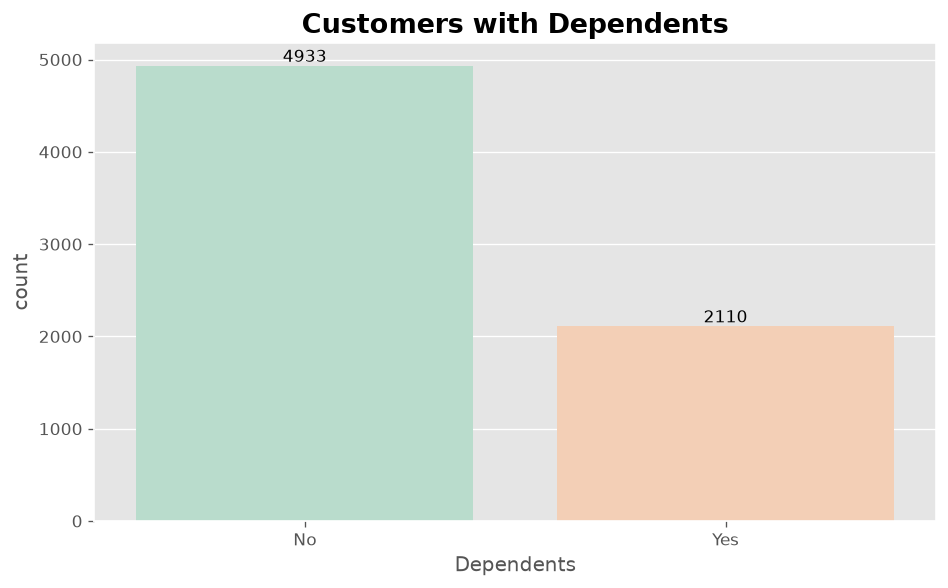

In [ ]:
# ==========================================
# Dependents Distribution Visualization
# ==========================================
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Dependents",
    hue="Dependents",
    palette="Pastel2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customers with Dependents", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### Business Observation

- A substantial proportion of customers (**4,933; 70.04%**) do not have dependents, while **2,110 customers (29.96%)** have dependents.
- This indicates that most customers are likely to make purchasing decisions independently rather than as part of a larger household.
- Customers with dependents may exhibit different retention behaviours, making this feature valuable for investigating customer churn.

In [ ]:
# ==========================================
# Internet Service Distribution
# ==========================================
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

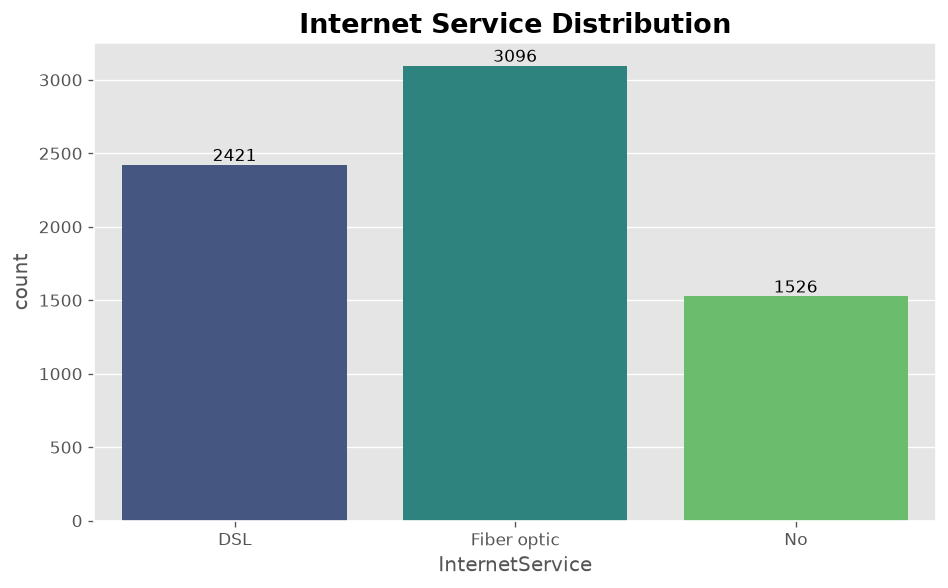

In [ ]:
# ==========================================
# Internet Service Distribution Visualization
# ==========================================
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="InternetService",
    hue="InternetService",
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Internet Service Distribution", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### Business Observation

- **Fiber optic** is the most widely used internet service, with **3,096 customers (43.96%)**, followed by **DSL** with **2,421 customers (34.38%)**.
- Approximately **1,526 customers (21.67%)** do not subscribe to any internet service.
- The high adoption of Fiber optic services suggests it is a core product offered by the telecom provider.
- Differences in customer satisfaction, pricing, or service quality across internet service types may influence churn and will be explored in subsequent analyses.

In [ ]:
# ==========================================
# Contract Type Distribution
# ==========================================
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

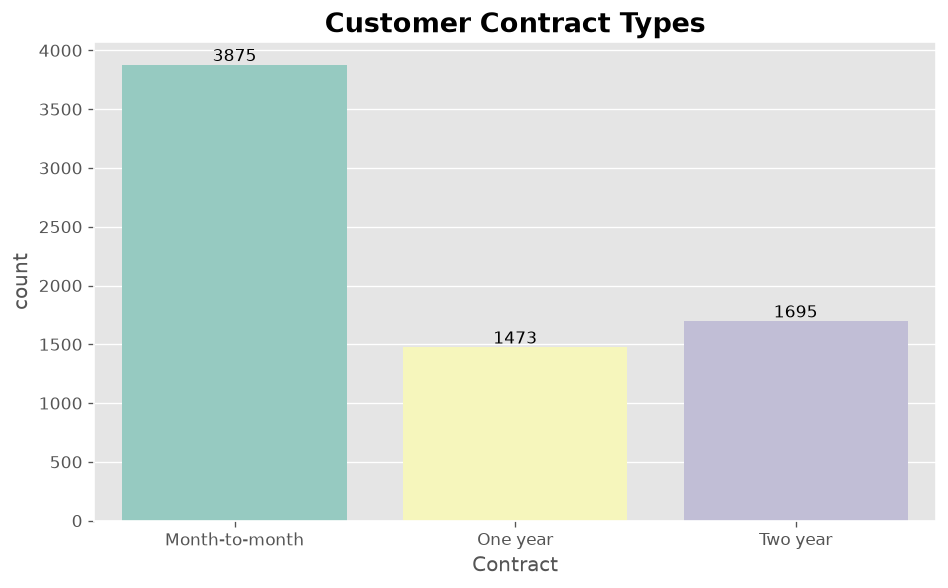

In [ ]:
# ==========================================
# Contract Type Distribution Visualization
# ==========================================
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Contract",
    hue="Contract",
   palette="Set3",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Contract Types", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### Business Observation

- **Month-to-month contracts** are the most common, accounting for **3,875 customers (55.02%)**.
- **Two-year contracts** represent **1,695 customers (24.07%)**, while **one-year contracts** account for **1,473 customers (20.91%)**.
- The predominance of month-to-month contracts suggests that many customers prefer flexible subscription plans over long-term commitments.
- Because customers on shorter contracts have greater flexibility to discontinue service, contract type is expected to play a significant role in customer retention and churn prediction.

# Churn Analysis by Customer Characteristics

This section investigates how customer characteristics influence churn.

Each analysis compares customer groups against the target variable (**Churn**) to identify potential predictors of customer attrition.

In [25]:
# ==========================================
# Churn by Gender
# ==========================================

gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"]
)

gender_churn

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


In [ ]:
# ==========================================
# Churn by Gender %
# ==========================================
gender_churn_percent = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
).round(3) * 100

gender_churn_percent

Churn,No,Yes
gender,,
Female,73.1,26.9
Male,73.8,26.2


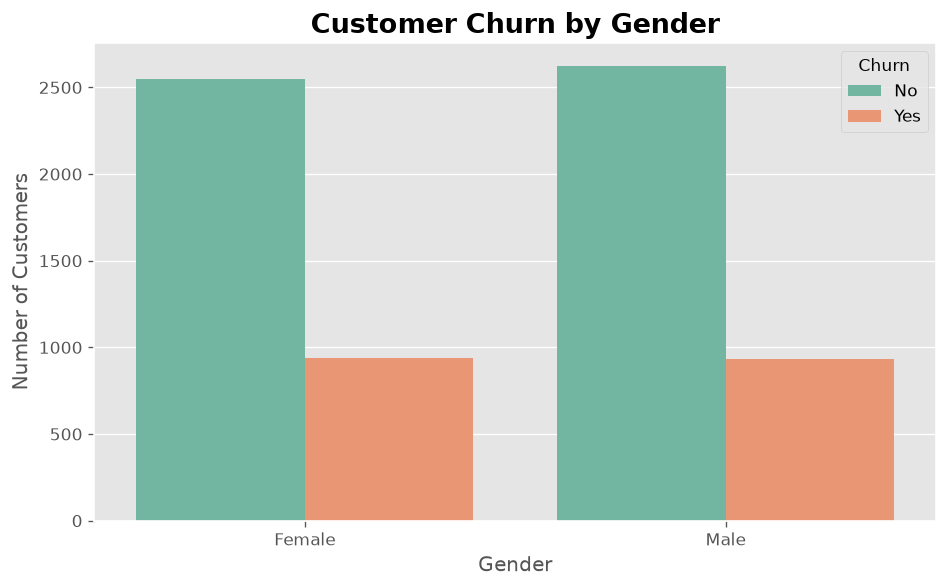

In [ ]:
# ==========================================
# Churn by Gender Visualization
# ==========================================
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn",
    palette="Set2"
)

plt.title("Customer Churn by Gender",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Gender")

plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()

### Business Observation

- Male and female customers exhibit similar churn behaviour.
- No substantial difference is observed between genders.
- Gender alone is unlikely to be a strong predictor of churn.

In [28]:
# ==========================================
# Churn by Senior Citizen Status
# ==========================================

senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"]
)

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,4508,1393
1,666,476


In [ ]:
# ==========================================
# Churn by Senior Citizen Status %
# ==========================================
senior_percent = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
).round(3) * 100

senior_percent

Churn,No,Yes
SeniorCitizen,,
0,76.4,23.6
1,58.3,41.7


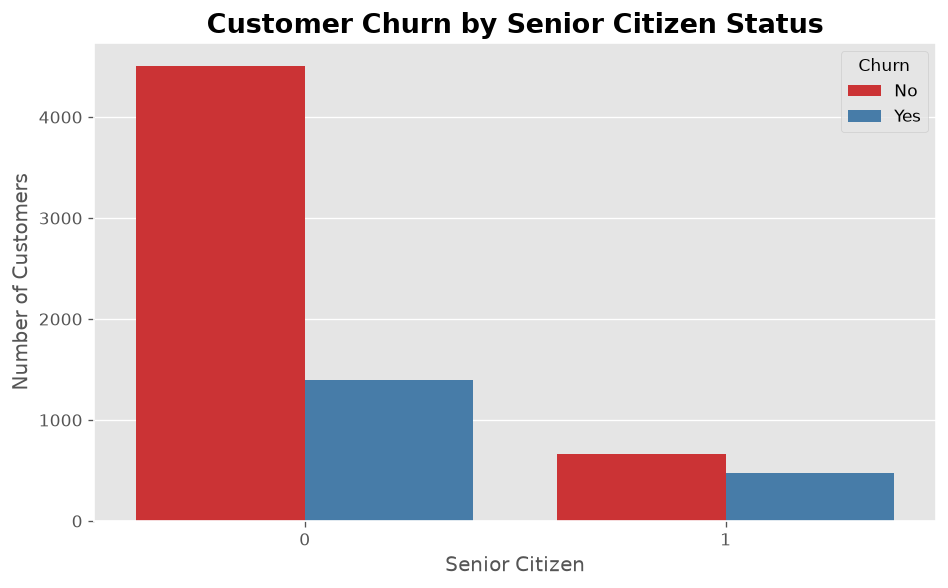

In [ ]:
# ==========================================
# Churn by Senior Citizen Status Visualization
# ==========================================
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn",
    palette="Set1"
)

plt.title(
    "Customer Churn by Senior Citizen Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Senior Citizen")

plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()

### Business Observation

- Senior citizens experience a noticeably higher churn rate than non-senior customers.
- This suggests that age-related factors may influence customer retention.
- Senior citizens may require targeted retention strategies.

In [38]:

# ==========================================
# Churn by Partner Status
# ==========================================
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"]
)

partner_churn

Churn,No,Yes
Partner,,
No,2441,1200
Yes,2733,669


In [ ]:
# ==========================================
# Churn by Partner Status %
# ==========================================

partner_percent = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
).round(3) * 100

partner_percent

Churn,No,Yes
Partner,,
No,67.0,33.0
Yes,80.3,19.7


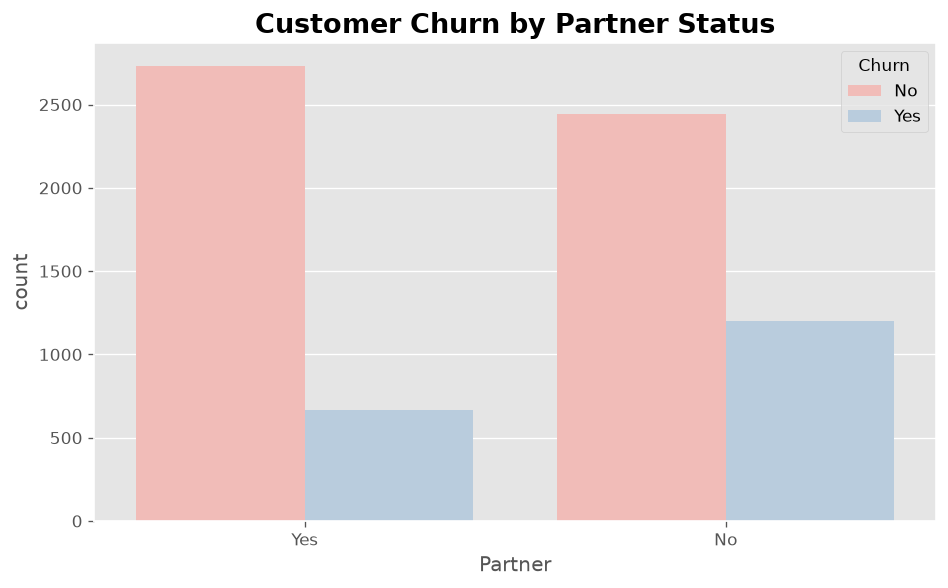

In [ ]:
# ==========================================
# Customer Churn by Partner Status Visualization
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Partner",
    hue="Churn",
    palette="Pastel1"
)

plt.title(
    "Customer Churn by Partner Status",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================
# Churn by Dependents Status
# ==========================================

dependent_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"]
)

dependent_churn

Churn,No,Yes
Dependents,,
No,3390,1543
Yes,1784,326


In [ ]:
# ==========================================
# Churn by Dependents Status %
# ==========================================

dependent_percent = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
).round(3) * 100

dependent_percent

Churn,No,Yes
Dependents,,
No,68.7,31.3
Yes,84.5,15.5


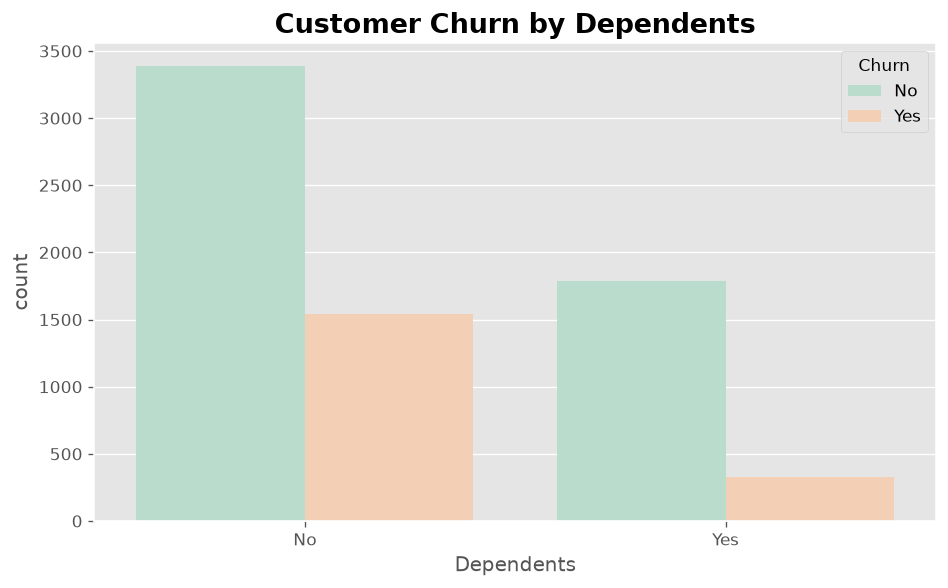

In [ ]:
# ==========================================
# Churn by Dependents Status Visualization
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Dependents",
    hue="Churn",
    palette="Pastel2"
)

plt.title(
    "Customer Churn by Dependents",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

---
# Business Question 7

## Does Contract Type Influence Customer Churn?

This analysis investigates whether contract duration affects customer retention.

In [39]:
# ==========================================
# Churn by Contract Type
# ==========================================

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [40]:
contract_percent = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

contract_percent

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


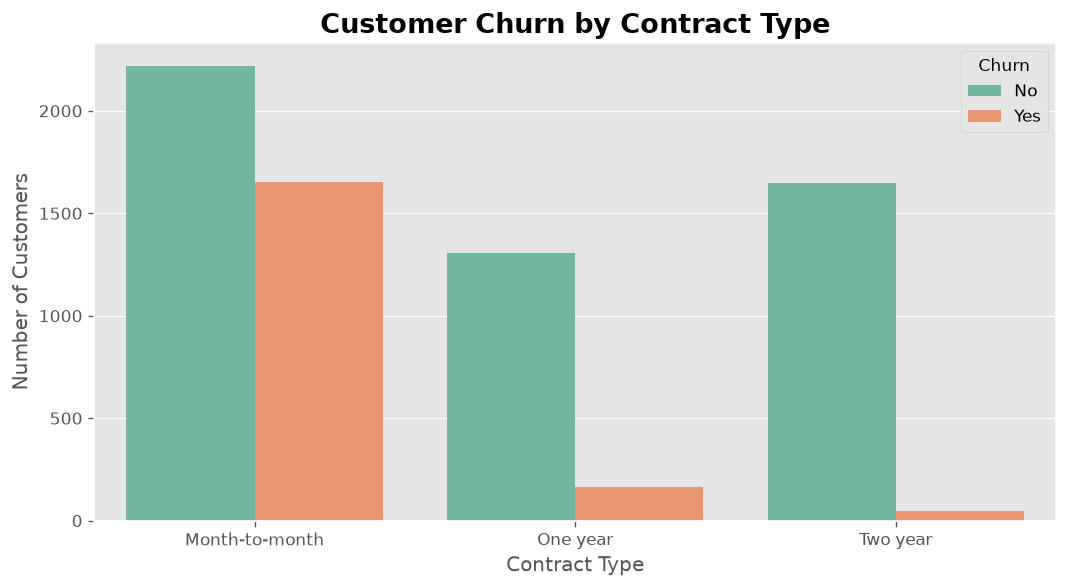

In [41]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn",
    palette="Set2"
)

plt.title(
    "Customer Churn by Contract Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Business Observation

- Customers on **month-to-month contracts** have the highest churn rate, with **42.71%** leaving the telecom provider.
- Customers on **one-year contracts** are significantly more loyal, with only **11.27%** churning.
- Customers on **two-year contracts** demonstrate the strongest retention, with a churn rate of just **2.83%**.
- These findings indicate that **contract duration is one of the strongest predictors of customer churn**.
- Encouraging customers to migrate from month-to-month plans to longer-term contracts could substantially improve customer retention and reduce revenue loss.

In [42]:

# ==========================================
# Churn by Internet Service
# ==========================================
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

internet_churn

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [43]:
contract_percent = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

contract_percent

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


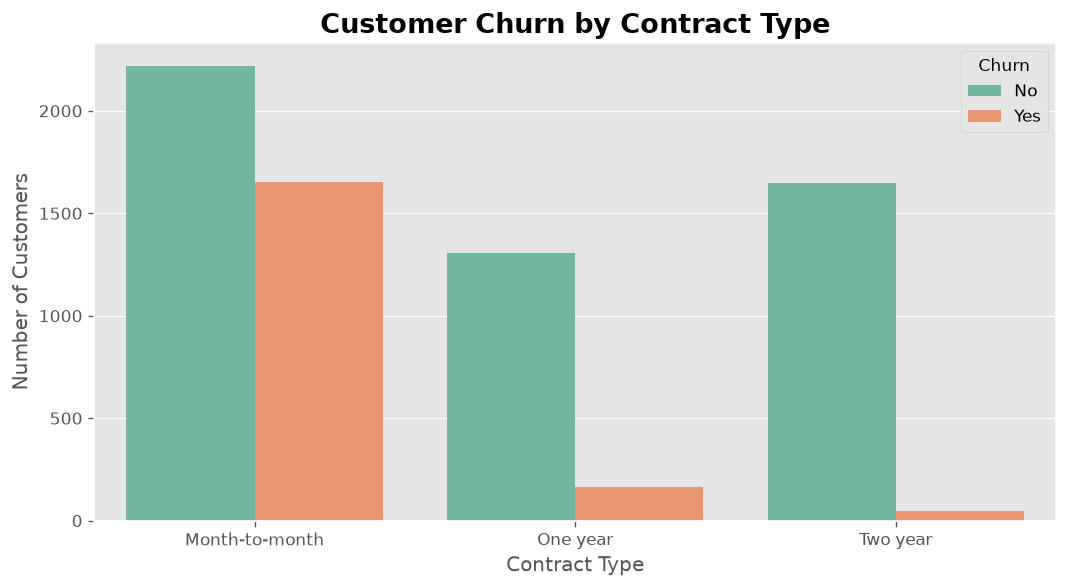

In [44]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn",
    palette="Set2"
)

plt.title(
    "Customer Churn by Contract Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Business Observation

- Churn rates vary considerably across internet service types.
- Customers using **Fiber optic** services exhibit the highest churn rate, suggesting possible concerns related to pricing, service quality, or customer expectations.
- Customers using **DSL** services appear more stable, while customers without internet service show the lowest churn rate.
- Internet service type appears to be an important predictor of customer churn and should be retained as a key feature during model development.

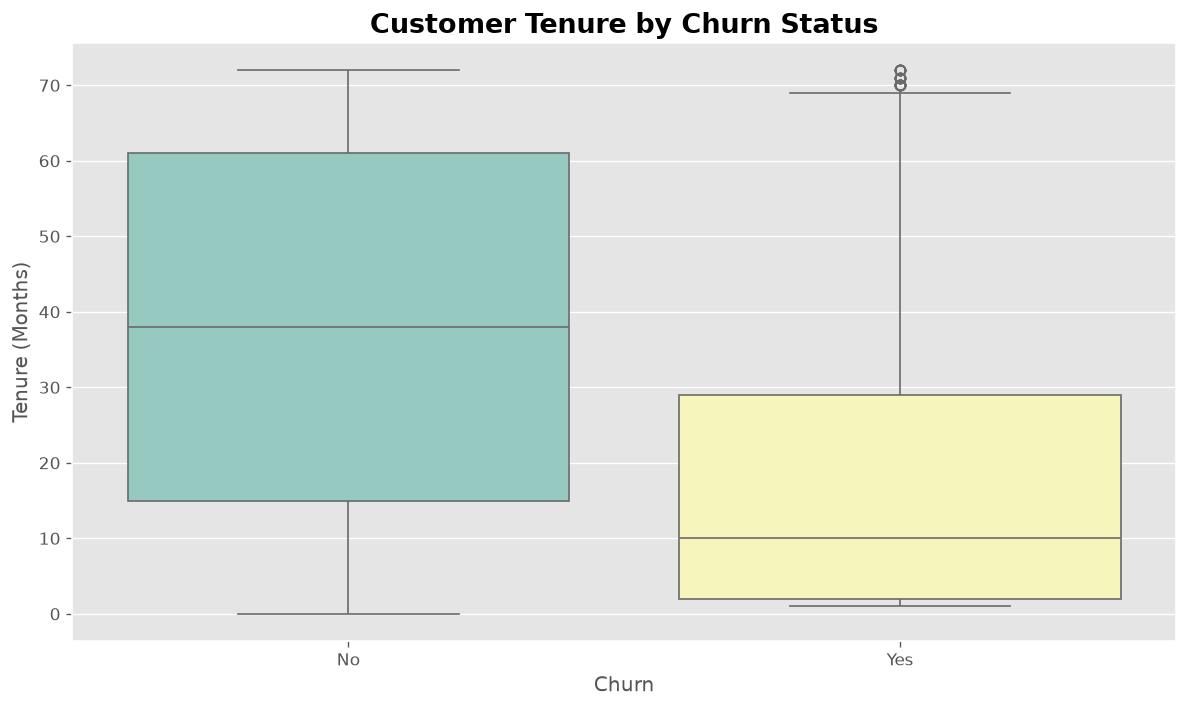

In [46]:
# ==========================================
# Churn by Tenure Influence
# ==========================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure",
    hue="Churn",
    palette="Set3",
    legend=False
)

plt.title(
    "Customer Tenure by Churn Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()

### Business Observation

- Customers who churn generally have **much shorter tenures** than customers who remain with the telecom provider.
- The median tenure of churned customers is substantially lower, indicating that many customers leave during the early stages of their subscription.
- Customers who remain tend to have longer relationships with the company, reflecting stronger loyalty and customer satisfaction.
- The presence of a few long-tenure customers who still churn suggests that customer attrition is influenced by multiple factors beyond tenure alone.
- Customer tenure is expected to be one of the most influential features in predicting churn and should be retained in the machine learning model.

# Executive Summary of Exploratory Data Analysis

## Key Findings

The exploratory analysis identified several customer characteristics that are strongly associated with customer churn.

### Major Insights

- Approximately **27%** of customers have churned, indicating a meaningful customer retention challenge.
- Gender does not appear to significantly influence customer churn.
- Senior citizens experience higher churn rates than non-senior customers.
- Customers without partners or dependents are more likely to churn.
- **Month-to-month contracts exhibit the highest churn rate (42.71%)**, while two-year contracts provide the strongest customer retention (2.83% churn).
- Customer tenure is strongly associated with churn, with newer customers significantly more likely to leave.
- Internet service type appears to influence customer retention and warrants further investigation during feature importance analysis.

## Business Implications

The analysis suggests that customer retention initiatives should prioritize:

1. Customers on month-to-month contracts.
2. Newly acquired customers with short tenures.
3. Senior citizens and customers without family commitments.
4. Customers using internet services associated with higher churn rates.

## Next Phase

The next stage of the project focuses on **Data Cleaning and Feature Engineering**, where hidden missing values will be addressed, categorical variables will be encoded, numerical features will be prepared, and the dataset will be transformed into a format suitable for machine learning model development.